# 04 — Independent Poisson models for football scores

This notebook builds an interpretable score model for each of the five leagues. Its primary output is a probability distribution over exact scores. The same distribution gives:

- the three probabilities for a **home win, draw, and away win**;
- the binary probability of a **home win versus a home non-win**;
- expected goals for both teams;
- inputs for the season simulation.

The model is deliberately narrower than the machine-learning classifiers. It uses final goal counts, team identities, venues, and match dates. This makes every parameter interpretable and allows future fixtures to be simulated without betting odds or match-day squad information.

All model choices are made from the two development folds. Results from 2024/25 are not opened here; that season remains the only final walk-forward test.

## 1. Data and literature sources

Match dates, teams, and final goals originate from [Understat](https://understat.com/). Notebook 01 documents the acquisition and cleaning procedure. ClubElo, SoFIFA, and betting-market variables are not inputs to this score model because the present specification estimates team attack and defence directly from observed goals.

The notation follows Sections 1.6 and 2.2.2 of the thesis. The football formulation is also consistent with Loukas et al. (2024), [*Predicting Football Match Results Using a Poisson Regression Model*](https://doi.org/10.3390/app14167230), and Penn and Donnelly (2022), [*Analysis of a double Poisson model for predicting football results in Euro 2020*](https://doi.org/10.1371/journal.pone.0268511). General GLM and count-data interpretation follows the textbooks cited in the thesis by Faraway, Dobson and Barnett, and Cameron and Trivedi.

In [1]:
from pathlib import Path
import os
import sys

ROOT = Path.cwd().resolve().parent
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".cache" / "matplotlib"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.config import DEVELOPMENT_SEASONS, FINAL_TEST_SEASON, PROCESSED_DATA_DIR
from src.evaluation import evaluate_binary, evaluate_multiclass
from src.poisson_models import (
    fit_poisson_model,
    league_parameter_table,
    parameter_table,
    poisson_diagnostics,
    poisson_probabilities,
    score_probability_matrix,
)
from src.validation import development_folds, summarize_folds, weighted_metric_summary

LEAGUES = {
    "BUNDESLIGA": "Bundesliga",
    "EPL": "Premier League",
    "LALIGA": "La Liga",
    "LIGUE_1": "Ligue 1",
    "SERIE_A": "Serie A",
}

COLOURS = {
    "navy": "#183B56",
    "blue": "#3E7CB1",
    "orange": "#F28E2B",
    "green": "#4E9F6D",
    "grey": "#D7DEE7",
    "red": "#C44E52",
}

plt.rcParams.update({
    "figure.figsize": (10, 5.5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 10,
    "font.size": 10,
    "grid.alpha": 0.22,
})
pd.set_option("display.max_columns", 30)

## 2. Modelling sample and chronology

The modelling sample contains seasons 2021/22–2023/24. The following season, 2024/25, has the role `walk_forward_test` and is excluded from every calculation in this notebook.

Two expanding folds imitate the information available at a real forecast date:

1. train on 2021/22 and validate on 2022/23, with weight 40%;
2. train on 2021/22–2022/23 and validate on 2023/24, with weight 60%.

The larger weight on the second fold reflects its greater temporal relevance and its larger training history. It does not allow later outcomes to enter an earlier fit.

In [2]:
matches = pd.read_csv(PROCESSED_DATA_DIR / "match_features.csv", parse_dates=["date"])
matches = matches.sort_values(["date", "league_id", "game_id"]).reset_index(drop=True)

development = matches.loc[
    matches["season_id"].isin(DEVELOPMENT_SEASONS)
    & matches["sample_role"].eq("development")
].copy()

assert development["season_id"].max() < FINAL_TEST_SEASON
assert development[["home_goals", "away_goals", "target_1x2", "home_win"]].notna().all().all()

sample_columns = [
    "date", "league_id", "season_id", "home_team", "away_team",
    "home_goals", "away_goals", "target_1x2", "sample_role",
]
display(development[sample_columns].sample(8, random_state=42))

,date,league_id,season_id,home_team,away_team,home_goals,away_goals,target_1x2,sample_role
2124,2022-09-16,LIGUE_1,2022,Auxerre,Lorient,1,3,A,development
4122,2023-10-29,LIGUE_1,2023,Brest,Paris Saint Germain,2,3,A,development
2867,2023-02-12,LALIGA,2022,Celta Vigo,Atletico Madrid,0,1,A,development
4283,2023-12-02,EPL,2023,Brentford,Luton,3,1,H,development
2596,2023-01-02,LIGUE_1,2022,Strasbourg,Troyes,2,3,A,development
952,2022-01-10,SERIE_A,2021,Torino,Fiorentina,4,0,H,development
3063,2023-03-12,EPL,2022,Newcastle United,Wolverhampton Wanderers,2,1,H,development
381,2021-10-16,EPL,2021,Manchester City,Burnley,2,0,H,development


The random sample above checks the analytical format without showing only the earliest dates. Every row is one completed match. `target_1x2` is derived from the two goal counts, while `home_win` equals one only when the home score is strictly greater than the away score.

In [3]:
fold_rows = []
for league_id, league_name in LEAGUES.items():
    league_data = development.loc[development["league_id"].eq(league_id)]
    timing = summarize_folds(league_data, development_folds(league_data))
    timing.insert(0, "league", league_name)
    fold_rows.append(timing)

fold_timing = pd.concat(fold_rows, ignore_index=True)
display(
    fold_timing.style
    .format({"weight": "{:.0%}", "last_train_date": "{:%d %b %Y}", "first_validation_date": "{:%d %b %Y}"})
    .hide(axis="index")
)

league,fold,weight,train_seasons,validation_season,train_matches,validation_matches,last_train_date,first_validation_date
Bundesliga,1,40%,2021,2022,306,306,14 May 2022,05 Aug 2022
Bundesliga,2,60%,"2021, 2022",2023,612,306,27 May 2023,18 Aug 2023
Premier League,1,40%,2021,2022,380,380,22 May 2022,05 Aug 2022
Premier League,2,60%,"2021, 2022",2023,760,380,28 May 2023,11 Aug 2023
La Liga,1,40%,2021,2022,380,380,22 May 2022,12 Aug 2022
La Liga,2,60%,"2021, 2022",2023,760,380,04 Jun 2023,11 Aug 2023
Ligue 1,1,40%,2021,2022,380,380,21 May 2022,05 Aug 2022
Ligue 1,2,60%,"2021, 2022",2023,760,306,03 Jun 2023,12 Aug 2023
Serie A,1,40%,2021,2022,380,380,22 May 2022,13 Aug 2022
Serie A,2,60%,"2021, 2022",2023,760,380,04 Jun 2023,19 Aug 2023


The table confirms a strict time boundary in every league. A validation match is always later than every match used to estimate its parameters. This is particularly important for team strengths: a model must not use goals scored later in the season to describe a team at an earlier forecast date.

## 3. Probability model

Let (X) denote home goals and (Y) away goals. The independent double-Poisson model assumes

$$
X \sim \operatorname{Poiss}(\lambda_H),
\qquad
Y \sim \operatorname{Poiss}(\lambda_A).
$$

For a Poisson random variable (Z),

$$
P(Z=z)=\frac{e^{-\lambda}\lambda^z}{z!},
\qquad z=0,1,2,\ldots,
$$

and both its expected value and variance equal (lambda):

$$
E(Z)=\operatorname{Var}(Z)=\lambda.
$$

The equality of mean and variance is called **equidispersion**. Football scores can violate it, so it will be checked rather than silently assumed.

### 3.1 Team attack, team defence, and home advantage

For a match with home team (H) and away team (A), the log link is

$$
\log(\lambda_H)=\mu+\mu_H+att_H+def_A,
$$

$$
\log(\lambda_A)=\mu+att_A+def_H.
$$

The symbols have the following meanings:

| Symbol | Meaning | Multiplicative interpretation |
|---|---|---|
| (lambda_H) | expected home goals in this fixture | model output after exponentiation |
| (lambda_A) | expected away goals in this fixture | model output after exponentiation |
| (mu) | league scoring level for two average teams | (e^\mu) is the baseline expected away-goal count |
| (mu_H) | home-advantage coefficient | (e^{\mu_H}) multiplies expected home goals |
| (att_t) | attack effect of team (t) | (e^{att_t}>1) means an above-average attack |
| (def_t) | defence effect of team (t) | (e^{def_t}>1) lets opponents score more, so defence is weaker |

The sign of (def_t) deserves care. It enters the **opponent's** goal intensity. A negative (def_t), and therefore (e^{def_t}<1), represents a stronger defence.

The log link guarantees (lambda_H>0) and (lambda_A>0). It also turns addition on the coefficient scale into multiplication on the expected-goal scale.

### 3.2 Identifiability

Without a constraint, the intercept and team effects can be shifted against one another without changing any fitted intensity. We therefore impose

$$
\sum_{t=1}^{T} att_t=0,
\qquad
\sum_{t=1}^{T} def_t=0,
$$

where (T) is the number of teams observed in the training data. Attack and defence are consequently measured relative to the average team in that league and training period.

The numerical optimisation estimates (T-1) attack effects and (T-1) defence effects. The final effect in each group is the negative sum of the others. Together with (mu) and (mu_H), the model has

$$
2+2(T-1)=2T
$$

free parameters.

### 3.3 Exact-score and match-result probabilities

Conditional independence gives an exact-score probability as the product of the two Poisson probabilities:

$$
P(X=x,Y=y)
=\frac{e^{-\lambda_H}\lambda_H^x}{x!}
 \frac{e^{-\lambda_A}\lambda_A^y}{y!}.
$$

The 1X2 probabilities are sums over regions of the score matrix:

$$
P(1)=P(X>Y),\qquad
P(X)=P(X=Y),\qquad
P(2)=P(X<Y).
$$

For the binary task used later,

$$
P(\text{home win})=P(X>Y),
\qquad
P(\text{home non-win})=1-P(X>Y).
$$

The implementation evaluates scores from 0 to 10 goals for each team and normalises their joint mass. The omitted tail is reported for an example fixture below.

## 4. Parameter estimation

For match (i), let the observed scores be (x_i) and (y_i). Under independence, the likelihood for all (n) training matches is

$$
L(\theta)=\prod_{i=1}^{n}
\frac{e^{-\lambda_{H,i}}\lambda_{H,i}^{x_i}}{x_i!}
\frac{e^{-\lambda_{A,i}}\lambda_{A,i}^{y_i}}{y_i!},
$$

where (	heta=(\mu,\mu_H,att_1,\ldots,def_T)) subject to the two zero-sum constraints. The maximum-likelihood estimate is

$$
\widehat{\theta}=\arg\max_{\theta}\ell(\theta),
$$

with log-likelihood

$$
\ell(\theta)=\sum_{i=1}^{n}
\left[x_i\log\lambda_{H,i}-\lambda_{H,i}-\log(x_i!)
+y_i\log\lambda_{A,i}-\lambda_{A,i}-\log(y_i!)\right].
$$

All coefficients are estimated **jointly** by L-BFGS-B numerical optimisation. They are not raw averages of goals. Joint estimation separates, for example, a strong attack from the weak defences it happened to face.

### 4.1 Optional time weighting

Football strength changes over time. Three transparent specifications are compared:

- no time decay;
- a 730-day half-life;
- a 365-day half-life.

For an observation (Delta t_i) days before the final training date,

$$
w_i=\exp(-\xi\Delta t_i),
\qquad
\xi=\frac{\log 2}{h},
$$

where (h) is the half-life in days. The weighted log-likelihood is

$$
\ell_w(\theta)=\sum_{i=1}^{n}w_i\ell_i(\theta).
$$

Thus a match exactly (h) days old receives half the weight of a match at the training boundary. Half-life is selected only from chronological development performance.

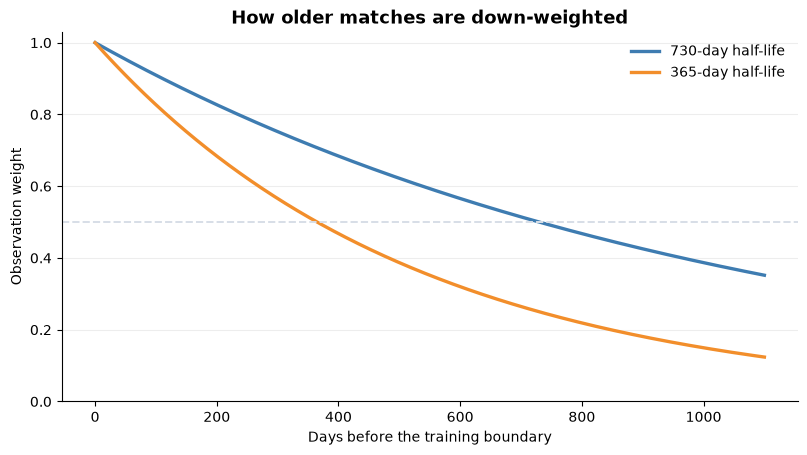

In [4]:
POISSON_CONFIGS = pd.DataFrame([
    {"configuration": "No time decay", "half_life_days": np.inf, "decay_rate": 0.0},
    {"configuration": "730-day half-life", "half_life_days": 730.0, "decay_rate": np.log(2) / 730.0},
    {"configuration": "365-day half-life", "half_life_days": 365.0, "decay_rate": np.log(2) / 365.0},
])

ages = np.arange(0, 1101)
fig, ax = plt.subplots(figsize=(9.5, 4.8))
for row, colour in zip(POISSON_CONFIGS.iloc[1:].itertuples(index=False), [COLOURS["blue"], COLOURS["orange"]]):
    ax.plot(ages, np.exp(-row.decay_rate * ages), label=row.configuration, color=colour, linewidth=2.4)
ax.axhline(0.5, color=COLOURS["grey"], linestyle="--", linewidth=1.4)
ax.set(title="How older matches are down-weighted", xlabel="Days before the training boundary", ylabel="Observation weight")
ax.set_ylim(0, 1.03)
ax.grid(axis="y")
ax.legend(frameon=False)
plt.show()

The 365-day curve adapts faster but uses less effective information. The 730-day curve is more stable. No-decay gives every match equal weight. Chronological validation decides whether adaptation compensates for the additional variance.

Approximate standard errors are calculated from the model-based Poisson information matrix,

$$
\widehat{\operatorname{Var}}(\widehat\theta)=(X^T\widehat W X)^{-1}.
$$

They quantify sampling uncertainty under the assumed Poisson mean-variance relation. If equidispersion or independence fails, these intervals can be too optimistic and should be read as descriptive rather than definitive inferential statements.

## 5. Chronological validation

Each league is estimated separately because scoring levels, home advantage, and team effects are league-specific. A pooled team-effect Poisson model is not treated as a comparable sixth branch: league match networks are disconnected because the data contain no cross-league fixtures, while each competition also needs its own scoring level and home advantage. The pooled structural and market classifiers remain valid comparisons in Notebook 03 because their inputs are numerical pre-match differences rather than one coefficient for every club identity.

Every Poisson configuration is evaluated on both folds for two tasks:

- **1X2:** accuracy, logarithmic loss, multiclass Brier score, and draw recall;
- **binary:** accuracy, logarithmic loss, and Brier score for home win versus home non-win.

Accuracy measures the proportion of correct hard decisions. Log-loss and Brier score evaluate the full probabilities and penalise unjustified confidence. Lower values are better for both probability scores.

In [5]:
fold_result_rows = []

for league_id, league_name in LEAGUES.items():
    league_data = development.loc[development["league_id"].eq(league_id)].copy()
    for fold in development_folds(league_data):
        train = league_data.loc[fold["train_index"]]
        validation = league_data.loc[fold["validation_index"]]
        for config in POISSON_CONFIGS.itertuples(index=False):
            fit = fit_poisson_model(train, decay_rate=config.decay_rate)
            probabilities, lambda_home, lambda_away = poisson_probabilities(fit, validation)
            result_1x2 = evaluate_multiclass(validation["target_1x2"], probabilities)
            result_binary = evaluate_binary(validation["home_win"], probabilities[:, 0])
            fold_result_rows.append({
                "league_id": league_id,
                "league": league_name,
                "configuration": config.configuration,
                "half_life_days": config.half_life_days,
                "decay_rate": config.decay_rate,
                "fold": fold["fold"],
                "weight": fold["weight"],
                "train_seasons": ", ".join(str(year) for year in fold["train_seasons"]),
                "validation_season": fold["validation_season"],
                "train_matches": len(train),
                "validation_matches": len(validation),
                "optimizer_success": fit.success,
                "mean_lambda_home": lambda_home.mean(),
                "mean_lambda_away": lambda_away.mean(),
                **result_1x2,
                **{f"binary_{key}": value for key, value in result_binary.items()},
            })

poisson_fold_results = pd.DataFrame(fold_result_rows)
assert poisson_fold_results["optimizer_success"].all()
print(f"Successful optimisations: {poisson_fold_results['optimizer_success'].sum()} / {len(poisson_fold_results)}")

Successful optimisations: 30 / 30


In [6]:
metric_columns = [
    "accuracy", "log_loss", "brier_score", "draw_recall",
    "binary_accuracy", "binary_log_loss", "binary_brier_score",
]
poisson_summary = weighted_metric_summary(
    poisson_fold_results,
    metric_columns=metric_columns,
    group_columns=["league_id", "league", "configuration", "half_life_days", "decay_rate"],
)

display_columns = [
    "league", "configuration", "accuracy", "log_loss", "brier_score",
    "draw_recall", "binary_accuracy", "binary_log_loss", "binary_brier_score",
]
display(
    poisson_summary[display_columns]
    .sort_values(["league", "accuracy"], ascending=[True, False])
    .style
    .format({
        "accuracy": "{:.2%}", "draw_recall": "{:.2%}", "binary_accuracy": "{:.2%}",
        "log_loss": "{:.4f}", "brier_score": "{:.4f}",
        "binary_log_loss": "{:.4f}", "binary_brier_score": "{:.4f}",
    })
    .background_gradient(subset=["accuracy", "binary_accuracy"], cmap="Blues")
    .hide(axis="index")
)

league,configuration,accuracy,log_loss,brier_score,draw_recall,binary_accuracy,binary_log_loss,binary_brier_score
Bundesliga,No time decay,49.08%,1.0169,0.6079,0.00%,65.03%,0.6449,0.2261
Bundesliga,730-day half-life,48.69%,1.0176,0.6084,0.00%,65.23%,0.6451,0.2263
Bundesliga,365-day half-life,48.56%,1.0183,0.6089,0.00%,64.38%,0.6453,0.2265
La Liga,730-day half-life,51.79%,0.9858,0.5883,0.45%,66.00%,0.6262,0.2180
La Liga,No time decay,51.63%,0.9865,0.5887,0.45%,65.21%,0.6265,0.2182
La Liga,365-day half-life,51.42%,0.9859,0.5883,0.45%,66.53%,0.6265,0.2180
Ligue 1,No time decay,48.70%,1.0369,0.6214,0.00%,64.01%,0.6382,0.2235
Ligue 1,365-day half-life,48.54%,1.0372,0.6211,0.00%,63.60%,0.6390,0.2237
Ligue 1,730-day half-life,48.42%,1.0367,0.6211,0.00%,64.01%,0.6383,0.2235
Premier League,365-day half-life,53.95%,0.9936,0.5915,0.00%,62.11%,0.6454,0.2262


The table keeps 1X2 and binary performance next to each other because both originate from the same score distribution. However, a good binary model is not automatically the best three-class model: much of the 1X2 difficulty is separating draws from away wins.

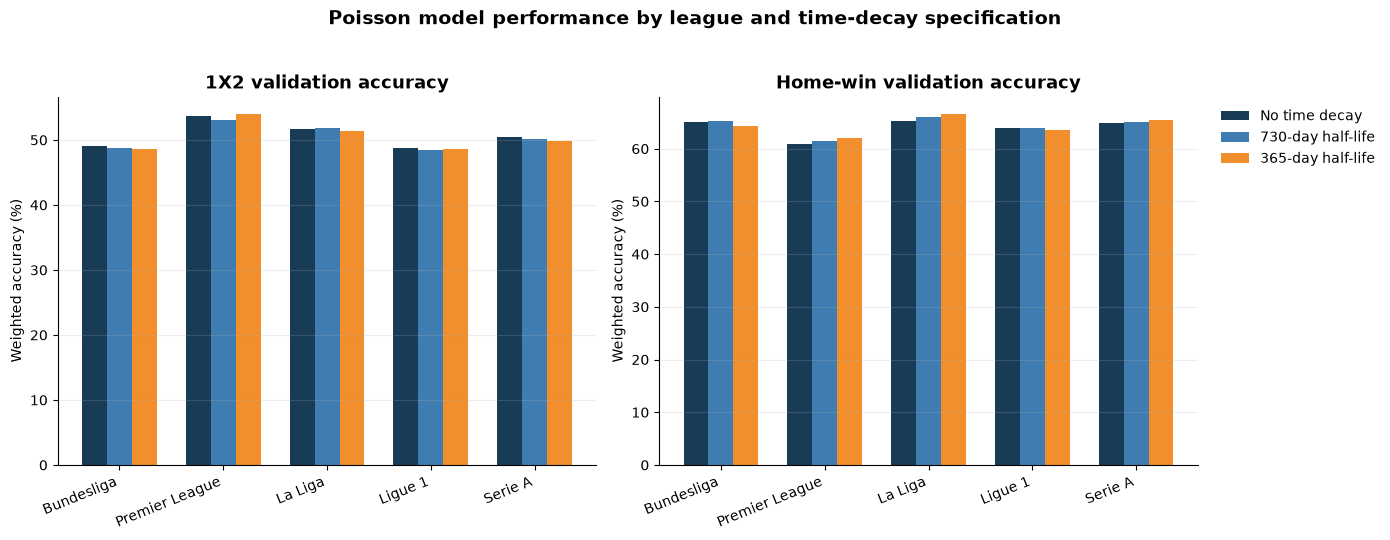

In [7]:
config_order = POISSON_CONFIGS["configuration"].tolist()
league_order = list(LEAGUES.values())
bar_width = 0.24
x = np.arange(len(league_order))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), sharey=False)
for position, (configuration, colour) in enumerate(zip(config_order, [COLOURS["navy"], COLOURS["blue"], COLOURS["orange"]])):
    subset = poisson_summary.loc[poisson_summary["configuration"].eq(configuration)].set_index("league").reindex(league_order)
    offset = (position - 1) * bar_width
    axes[0].bar(x + offset, 100 * subset["accuracy"], width=bar_width, label=configuration, color=colour)
    axes[1].bar(x + offset, 100 * subset["binary_accuracy"], width=bar_width, label=configuration, color=colour)

axes[0].set_title("1X2 validation accuracy")
axes[1].set_title("Home-win validation accuracy")
for ax in axes:
    ax.set_xticks(x, league_order, rotation=22, ha="right")
    ax.set_ylabel("Weighted accuracy (%)")
    ax.grid(axis="y")
axes[1].legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle("Poisson model performance by league and time-decay specification", fontsize=14, fontweight="bold", y=1.03)
fig.tight_layout()
plt.show()

### 5.1 Selection rule

The selected score model must support 1X2 prediction and season simulation. Selection therefore starts with weighted **1X2 accuracy**. Configurations within 0.5 percentage points of the best accuracy are treated as practically tied. Among them, lower 1X2 log-loss and then lower Brier score are preferred. If probability scores are also tied, the longer half-life is preferred because it uses information more stably; no decay is the simplest specification.

This rule is fixed before the final 2024/25 test. Binary validation metrics remain visible and will enter the dedicated comparison in Notebook 05.

In [8]:
def select_poisson_configuration(summary):
    selected_rows = []
    for league, group in summary.groupby("league", sort=False):
        best_accuracy = group["accuracy"].max()
        candidates = group.loc[group["accuracy"].ge(best_accuracy - 0.005)].copy()
        candidates["simplicity_rank"] = candidates["half_life_days"].replace(np.inf, 1e9)
        chosen = candidates.sort_values(
            ["log_loss", "brier_score", "simplicity_rank"],
            ascending=[True, True, False],
        ).iloc[0].copy()
        chosen["best_accuracy_in_league"] = best_accuracy
        chosen["accuracy_gap_to_best"] = best_accuracy - chosen["accuracy"]
        selected_rows.append(chosen)
    return pd.DataFrame(selected_rows).sort_values("league").reset_index(drop=True)


poisson_registry = select_poisson_configuration(poisson_summary)
display(
    poisson_registry[[
        "league", "configuration", "accuracy", "accuracy_gap_to_best", "log_loss",
        "brier_score", "draw_recall", "binary_accuracy", "binary_log_loss", "binary_brier_score",
    ]]
    .style
    .format({
        "accuracy": "{:.2%}", "accuracy_gap_to_best": "{:.2%}", "draw_recall": "{:.2%}",
        "binary_accuracy": "{:.2%}", "log_loss": "{:.4f}", "brier_score": "{:.4f}",
        "binary_log_loss": "{:.4f}", "binary_brier_score": "{:.4f}",
    })
    .hide(axis="index")
)

league,configuration,accuracy,accuracy_gap_to_best,log_loss,brier_score,draw_recall,binary_accuracy,binary_log_loss,binary_brier_score
Bundesliga,No time decay,49.08%,0.00%,1.0169,0.6079,0.00%,65.03%,0.6449,0.2261
La Liga,730-day half-life,51.79%,0.00%,0.9858,0.5883,0.45%,66.00%,0.6262,0.2180
Ligue 1,730-day half-life,48.42%,0.29%,1.0367,0.6211,0.00%,64.01%,0.6383,0.2235
Premier League,365-day half-life,53.95%,0.00%,0.9936,0.5915,0.00%,62.11%,0.6454,0.2262
Serie A,730-day half-life,50.11%,0.37%,1.0189,0.6113,0.00%,65.00%,0.6301,0.2195


The selected row for each league is the only Poisson specification carried into the interpretability analysis below. The reported validation values are estimates of development performance, not final-test results. The 2024/25 walk-forward evaluation is performed only after all model choices are frozen.

In [9]:
accuracy_min = poisson_registry["accuracy"].min()
accuracy_max = poisson_registry["accuracy"].max()
binary_min = poisson_registry["binary_accuracy"].min()
binary_max = poisson_registry["binary_accuracy"].max()
draw_max = poisson_registry["draw_recall"].max()
display(Markdown(
    f"**Development interpretation.** The selected league models reach **{accuracy_min:.2%}–{accuracy_max:.2%}** "
    f"weighted 1X2 accuracy and **{binary_min:.2%}–{binary_max:.2%}** binary accuracy. The 1X2 result is below "
    "the 58% aspiration and therefore cannot be presented as a final success. Draw recall is at most "
    f"**{draw_max:.2%}**: although the model assigns positive probability to a draw, that probability is almost never "
    "the largest of the three. The binary task is easier because a draw and an away win are combined into the same "
    "home non-win class."
))

**Development interpretation.** The selected league models reach **48.42%–53.95%** weighted 1X2 accuracy and **62.11%–66.00%** binary accuracy. The 1X2 result is below the 58% aspiration and therefore cannot be presented as a final success. Draw recall is at most **0.45%**: although the model assigns positive probability to a draw, that probability is almost never the largest of the three. The binary task is easier because a draw and an away win are combined into the same home non-win class.

## 6. Refit on the complete development period

After selection, each league model is re-estimated on all matches from 2021/22–2023/24. This refit uses more information than either individual fold and is the model available immediately before the 2024/25 season.

The exact inputs to every final Poisson fit are:

| Input | Role |
|---|---|
| `home_team` | selects (att_H) and (def_H) |
| `away_team` | selects (att_A) and (def_A) |
| `home_goals` | response (X) in the likelihood |
| `away_goals` | response (Y) in the likelihood |
| `date` | constructs the optional recency weight (w_i) |
| home/away status | activates the coefficient (mu_H) only for home goals |

No 1X2 label is needed to estimate the score model; it is used only for validation metrics. No market odds or engineered match statistics enter this specification.

In [10]:
final_poisson_fits = {}
league_parameter_rows = []
team_parameter_frames = []

for selected in poisson_registry.itertuples(index=False):
    league_data = development.loc[development["league_id"].eq(selected.league_id)].copy()
    fit = fit_poisson_model(league_data, decay_rate=selected.decay_rate)
    final_poisson_fits[selected.league_id] = fit

    league_table = league_parameter_table(fit)
    league_table.insert(0, "league", selected.league)
    league_table.insert(1, "configuration", selected.configuration)
    league_table["n_matches"] = fit.n_matches
    league_table["n_parameters"] = fit.n_parameters
    league_table["optimizer_success"] = fit.success
    league_parameter_rows.append(league_table)

    teams = parameter_table(fit)
    teams.insert(0, "league", selected.league)
    team_parameter_frames.append(teams)

poisson_league_parameters = pd.concat(league_parameter_rows, ignore_index=True)
poisson_team_parameters = pd.concat(team_parameter_frames, ignore_index=True)

display(
    poisson_league_parameters[[
        "league", "configuration", "parameter", "estimate", "approx_se",
        "exp_estimate", "n_matches", "n_parameters", "optimizer_success", "interpretation",
    ]]
    .style
    .format({"estimate": "{:.3f}", "approx_se": "{:.3f}", "exp_estimate": "{:.3f}"})
    .hide(axis="index")
)

league,configuration,parameter,estimate,approx_se,exp_estimate,n_matches,n_parameters,optimizer_success,interpretation
Bundesliga,No time decay,mu,0.224,0.033,1.250,918,44,True,Expected away goals for two average teams
Bundesliga,No time decay,mu_H,0.284,0.037,1.328,918,44,True,"Home-goal multiplier, teams held fixed"
La Liga,730-day half-life,mu,0.062,0.038,1.064,1140,48,True,Expected away goals for two average teams
La Liga,730-day half-life,mu_H,0.279,0.046,1.322,1140,48,True,"Home-goal multiplier, teams held fixed"
Ligue 1,730-day half-life,mu,0.185,0.039,1.203,1066,48,True,Expected away goals for two average teams
Ligue 1,730-day half-life,mu_H,0.163,0.046,1.177,1066,48,True,"Home-goal multiplier, teams held fixed"
Premier League,365-day half-life,mu,0.249,0.046,1.283,1140,50,True,Expected away goals for two average teams
Premier League,365-day half-life,mu_H,0.211,0.050,1.235,1140,50,True,"Home-goal multiplier, teams held fixed"
Serie A,730-day half-life,mu,0.130,0.037,1.139,1140,48,True,Expected away goals for two average teams
Serie A,730-day half-life,mu_H,0.172,0.046,1.187,1140,48,True,"Home-goal multiplier, teams held fixed"


For each league, (e^\mu) is the expected away-goal count when both teams have zero attack and defence effects—that is, when both are average under the zero-sum constraints. The home equivalent is (e^{\mu+\mu_H}). The value (e^{\mu_H}) is the proportional home multiplier after holding team identities fixed.

For example, (e^{\mu_H}=1.10) means that the model multiplies home expected goals by 1.10, or increases them by approximately 10%, relative to the same average-team baseline away from home. This is a multiplicative conditional statement, not a ten-percentage-point increase in win probability.

### 6.1 Team-specific attack and defence parameters

The next tables report all estimated team effects. They are separated by league so that the reference “average team” remains meaningful.

- `att`: coefficient (att_t); larger is a stronger attack.
- `exp_att`: multiplier (e^{att_t}) on the team's own expected goals.
- `def`: coefficient (def_t); smaller is a stronger defence.
- `exp_def`: multiplier (e^{def_t}) on the opponent's expected goals.
- `approx_se`: model-based standard error under the Poisson assumptions.

An attack multiplier of 1.20 means 20% more expected goals than an average attack, with opponent and venue held fixed. A defence multiplier of 0.80 means the team allows 20% fewer expected goals than an average defence, with opponent and venue held fixed.

In [11]:
team_display_columns = [
    "team", "att", "att_approx_se", "exp_att",
    "def", "def_approx_se", "exp_def",
]
for league_name in sorted(poisson_team_parameters["league"].unique()):
    display(Markdown(f"#### Estimated team parameters — {league_name}"))
    league_teams = poisson_team_parameters.loc[
        poisson_team_parameters["league"].eq(league_name), team_display_columns
    ].sort_values("att", ascending=False)
    display(
        league_teams.style
        .format({column: "{:.3f}" for column in team_display_columns if column != "team"})
        .background_gradient(subset=["att"], cmap="Blues")
        .background_gradient(subset=["def"], cmap="Oranges")
        .hide(axis="index")
    )

#### Estimated team parameters — Bundesliga

team,att,att_approx_se,exp_att,def,def_approx_se,exp_def
Bayern Munich,0.657,0.062,1.929,-0.277,0.089,0.758
Borussia Dortmund,0.482,0.067,1.619,-0.147,0.083,0.863
Bayer Leverkusen,0.431,0.068,1.539,-0.298,0.089,0.742
RasenBallsport Leipzig,0.371,0.070,1.449,-0.329,0.091,0.720
Hoffenheim,0.180,0.077,1.198,0.105,0.073,1.111
VfB Stuttgart,0.122,0.078,1.130,-0.064,0.079,0.938
Borussia M.Gladbach,0.120,0.079,1.128,0.102,0.073,1.107
Eintracht Frankfurt,0.058,0.081,1.059,-0.094,0.080,0.910
Freiburg,0.057,0.081,1.058,-0.114,0.081,0.892
FC Heidenheim,0.040,0.137,1.040,-0.021,0.130,0.979


#### Estimated team parameters — La Liga

team,att,att_approx_se,exp_att,def,def_approx_se,exp_def
Real Madrid,0.554,0.081,1.741,-0.458,0.127,0.632
Girona,0.486,0.095,1.626,0.016,0.114,1.016
Barcelona,0.456,0.085,1.579,-0.329,0.119,0.720
Atletico Madrid,0.396,0.087,1.486,-0.203,0.111,0.816
Villarreal,0.331,0.090,1.392,0.030,0.100,1.031
Levante,0.140,0.202,1.150,0.446,0.168,1.563
Athletic Club,0.111,0.099,1.118,-0.246,0.113,0.782
Real Betis,0.090,0.100,1.094,-0.156,0.108,0.856
Sevilla,0.061,0.102,1.063,-0.032,0.102,0.969
Espanyol,0.037,0.138,1.037,0.235,0.119,1.265


#### Estimated team parameters — Ligue 1

team,att,att_approx_se,exp_att,def,def_approx_se,exp_def
Paris Saint Germain,0.615,0.080,1.849,-0.313,0.116,0.731
Monaco,0.397,0.088,1.488,-0.092,0.104,0.912
Rennes,0.352,0.090,1.422,-0.183,0.108,0.833
Lyon,0.267,0.094,1.305,0.000,0.099,1.000
Marseille,0.255,0.094,1.291,-0.242,0.111,0.785
Lens,0.203,0.096,1.225,-0.338,0.116,0.713
Lille,0.184,0.097,1.202,-0.254,0.111,0.776
Montpellier,0.128,0.100,1.137,0.064,0.096,1.066
Brest,0.079,0.102,1.082,-0.138,0.105,0.871
Bordeaux,0.061,0.203,1.063,0.516,0.153,1.675


#### Estimated team parameters — Premier League

team,att,att_approx_se,exp_att,def,def_approx_se,exp_def
Manchester City,0.584,0.091,1.793,-0.617,0.147,0.540
Arsenal,0.479,0.095,1.615,-0.512,0.140,0.599
Liverpool,0.450,0.096,1.569,-0.366,0.130,0.693
Newcastle United,0.350,0.101,1.419,-0.099,0.115,0.906
Tottenham,0.310,0.103,1.363,-0.010,0.109,0.990
Chelsea,0.236,0.106,1.266,-0.093,0.113,0.911
Aston Villa,0.209,0.108,1.232,-0.081,0.113,0.922
Manchester United,0.092,0.113,1.096,-0.126,0.115,0.881
Brighton,0.067,0.115,1.070,-0.072,0.112,0.931
Fulham,0.052,0.124,1.053,-0.055,0.120,0.946


#### Estimated team parameters — Serie A

team,att,att_approx_se,exp_att,def,def_approx_se,exp_def
Inter,0.543,0.081,1.722,-0.480,0.127,0.619
AC Milan,0.406,0.087,1.501,-0.149,0.108,0.862
Atalanta,0.386,0.087,1.471,-0.091,0.105,0.913
Napoli,0.332,0.089,1.394,-0.280,0.114,0.756
Lazio,0.223,0.094,1.249,-0.230,0.111,0.795
Roma,0.222,0.094,1.248,-0.170,0.108,0.843
Fiorentina,0.220,0.094,1.247,-0.094,0.104,0.910
Juventus,0.148,0.097,1.160,-0.420,0.122,0.657
Bologna,0.098,0.100,1.103,-0.188,0.109,0.829
Sassuolo,0.069,0.102,1.071,0.299,0.087,1.349


The colour scales are descriptive aids, not separate hypothesis tests. Comparisons are safest within a league because each league has its own (mu), (mu_H), opponents, and selected time weighting. A team observed for fewer matches—for example after promotion—usually has a less stable estimate.

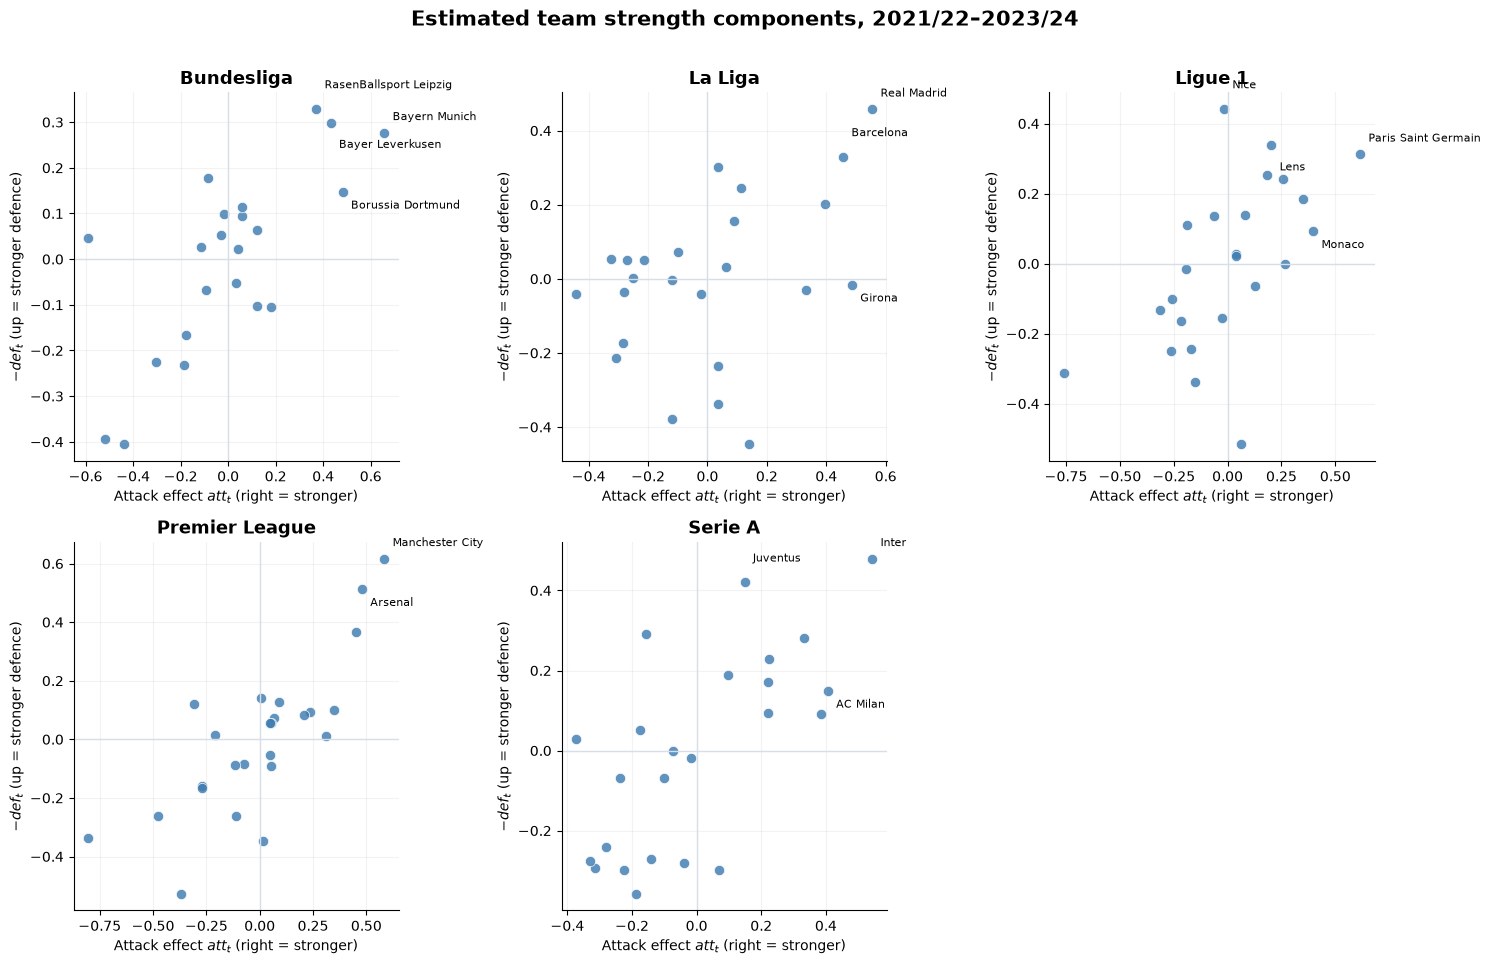

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9.5))
axes = axes.ravel()

for ax, league_name in zip(axes, sorted(poisson_team_parameters["league"].unique())):
    table = poisson_team_parameters.loc[poisson_team_parameters["league"].eq(league_name)].copy()
    ax.scatter(table["att"], -table["def"], s=55, color=COLOURS["blue"], alpha=0.82, edgecolor="white", linewidth=0.6)
    notable = pd.concat([
        table.nlargest(2, "att"),
        table.nsmallest(2, "def"),
    ]).drop_duplicates("team")
    offsets = [(6, 9), (6, -12), (6, 15), (6, -18)]
    for label_number, (_, row) in enumerate(notable.iterrows()):
        ax.annotate(
            row["team"], (row["att"], -row["def"]),
            xytext=offsets[label_number % len(offsets)], textcoords="offset points", fontsize=8,
        )
    ax.axvline(0, color=COLOURS["grey"], linewidth=1)
    ax.axhline(0, color=COLOURS["grey"], linewidth=1)
    ax.set_title(league_name)
    ax.set_xlabel(r"Attack effect $att_t$ (right = stronger)")
    ax.set_ylabel(r"$-def_t$ (up = stronger defence)")
    ax.grid(alpha=0.16)

axes[-1].axis("off")
fig.suptitle("Estimated team strength components, 2021/22–2023/24", fontsize=15, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

The upper-right part of each panel contains teams estimated to be strong in both components: positive attack and negative defence coefficients. The plot uses (-def_t) on the vertical axis solely to make “higher is stronger” visually consistent; the fitted equations continue to use (def_t) exactly as defined above.

## 7. From intensities to an exact-score matrix

The following Premier League example shows the complete calculation for Manchester City at home to Liverpool. It is an illustration from the refitted development model, not a claim about a particular 2024/25 fixture date.

In [13]:
example_league_id = "EPL"
example_home = "Manchester City"
example_away = "Liverpool"
example_fit = final_poisson_fits[example_league_id]

score_matrix, lambda_home, lambda_away, captured_mass = score_probability_matrix(
    example_fit, example_home, example_away, max_goals=10
)
example_probabilities, _, _ = poisson_probabilities(
    example_fit,
    pd.DataFrame({"home_team": [example_home], "away_team": [example_away]}),
    max_goals=10,
)

example_summary = pd.DataFrame({
    "quantity": [r"lambda_H", r"lambda_A", "P(home win)", "P(draw)", "P(away win)", "captured score mass"],
    "value": [lambda_home, lambda_away, *example_probabilities[0], captured_mass],
})
display(example_summary.style.format({"value": "{:.4f}"}).hide(axis="index"))

quantity,value
lambda_H,1.9702
lambda_A,1.0864
P(home win),0.5789
P(draw),0.2163
P(away win),0.2048
captured score mass,1.0000


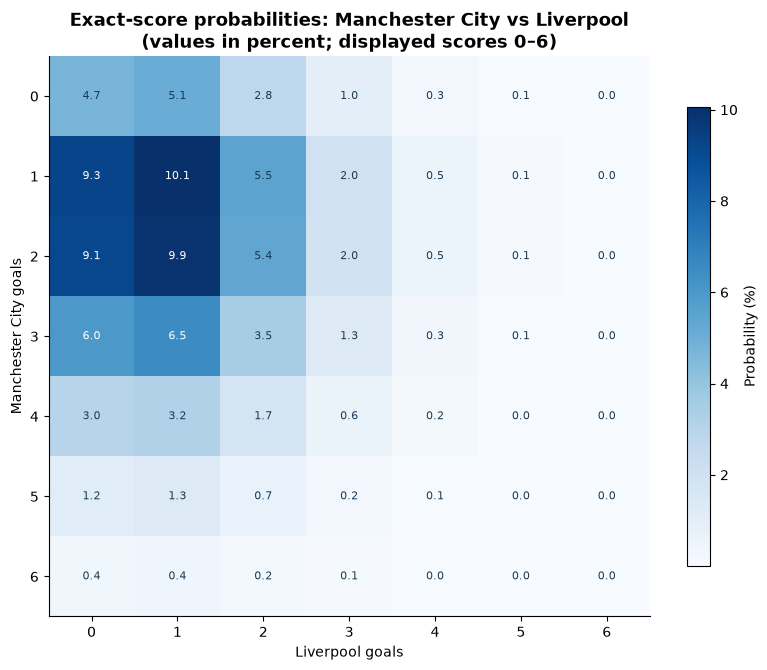

In [14]:
visible = score_matrix.iloc[:7, :7] * 100
fig, ax = plt.subplots(figsize=(8.2, 6.8))
image = ax.imshow(visible, cmap="Blues", aspect="auto")
for home_goals in range(visible.shape[0]):
    for away_goals in range(visible.shape[1]):
        value = visible.iloc[home_goals, away_goals]
        ax.text(away_goals, home_goals, f"{value:.1f}", ha="center", va="center", color="white" if value > visible.to_numpy().max() * 0.55 else COLOURS["navy"], fontsize=8)
ax.set_xticks(range(7), visible.columns)
ax.set_yticks(range(7), visible.index)
ax.set_xlabel(f"{example_away} goals")
ax.set_ylabel(f"{example_home} goals")
ax.set_title(f"Exact-score probabilities: {example_home} vs {example_away}\n(values in percent; displayed scores 0–6)")
fig.colorbar(image, ax=ax, label="Probability (%)", shrink=0.82)
fig.tight_layout()
plt.show()

Each cell is the product of one home-goal and one away-goal Poisson probability. Cells below the main diagonal correspond to a home win because the row score exceeds the column score. The diagonal represents draws; cells above it represent away wins. The numerical aggregation uses 0–10 goals, while the figure stops at six for readability. `captured score mass` shows how much joint probability lies inside the numerical grid before normalisation.

## 8. Diagnostics of the modelling assumptions

Interpretability does not make the assumptions automatically correct. Four aspects are examined on the complete development sample of each league:

1. **raw variance-to-mean ratios** for home and away goals; a value of one supports equidispersion;
2. **Pearson dispersion**, calculated as

$$
\widehat\phi=
\frac{\sum_i (x_i-\widehat\lambda_{H,i})^2/\widehat\lambda_{H,i}
+\sum_i (y_i-\widehat\lambda_{A,i})^2/\widehat\lambda_{A,i}}
{2n-p},
$$

where (p) is the number of fitted parameters;
3. the observed correlation between home and away goals;
4. a chi-square independence test on a capped (0,1,2,3,4+) score table.

Values of (widehat\phi) materially above one indicate residual overdispersion; values below one indicate underdispersion. A small chi-square p-value is evidence against unconditional score independence, although the test does not isolate its football mechanism.

In [15]:
diagnostic_rows = []
fit_check_rows = []

for league_id, league_name in LEAGUES.items():
    league_data = development.loc[development["league_id"].eq(league_id)].copy()
    fit = final_poisson_fits[league_id]
    diagnostics = poisson_diagnostics(fit, league_data)
    diagnostics.insert(0, "league", league_name)
    diagnostic_rows.append(diagnostics)

    _, fitted_home, fitted_away = poisson_probabilities(fit, league_data)
    fit_check_rows.append({
        "league": league_name,
        "observed_mean_home_goals": league_data["home_goals"].mean(),
        "fitted_mean_home_goals": fitted_home.mean(),
        "observed_mean_away_goals": league_data["away_goals"].mean(),
        "fitted_mean_away_goals": fitted_away.mean(),
    })

poisson_diagnostic_table = pd.concat(diagnostic_rows, ignore_index=True).pivot(
    index="league", columns="diagnostic", values="value"
).reset_index()
poisson_fit_check = pd.DataFrame(fit_check_rows)

display(Markdown("### Observed and fitted scoring levels"))
display(poisson_fit_check.style.format({column: "{:.3f}" for column in poisson_fit_check.columns if column != "league"}).hide(axis="index"))

display(Markdown("### Assumption diagnostics"))
display(poisson_diagnostic_table.style.format({column: "{:.3f}" for column in poisson_diagnostic_table.columns if column != "league"}).hide(axis="index"))

### Observed and fitted scoring levels

league,observed_mean_home_goals,fitted_mean_home_goals,observed_mean_away_goals,fitted_mean_away_goals
Bundesliga,1.808,1.808,1.362,1.362
Premier League,1.649,1.704,1.334,1.380
La Liga,1.454,1.466,1.100,1.109
Ligue 1,1.510,1.509,1.266,1.282
Serie A,1.450,1.442,1.230,1.215


### Assumption diagnostics

league,Away goals variance / mean,Capped-score independence chi-square,Capped-score independence p-value,Home goals variance / mean,Home-away goal correlation,Pearson dispersion
Bundesliga,1.147,43.583,0.000,1.145,-0.163,0.966
La Liga,1.067,18.534,0.294,1.094,0.030,0.943
Ligue 1,1.025,14.774,0.541,1.098,-0.050,0.920
Premier League,1.161,36.640,0.002,1.147,-0.156,0.955
Serie A,1.038,18.001,0.324,1.021,-0.073,0.912


In [16]:
dispersion_min = poisson_diagnostic_table["Pearson dispersion"].min()
dispersion_max = poisson_diagnostic_table["Pearson dispersion"].max()
rejected = poisson_diagnostic_table.loc[
    poisson_diagnostic_table["Capped-score independence p-value"].lt(0.05), "league"
].tolist()
rejected_text = ", ".join(rejected) if rejected else "no league"
display(Markdown(
    f"**Diagnostic interpretation.** Pearson dispersion ranges from **{dispersion_min:.3f} to {dispersion_max:.3f}**, "
    "so these aggregate fits do not show residual overdispersion. The capped-score independence test rejects at the "
    f"5% level for **{rejected_text}**. The fitted mean can differ slightly from the ordinary observed mean when time "
    "decay is selected, because recent matches contribute more to the likelihood."
))

**Diagnostic interpretation.** Pearson dispersion ranges from **0.912 to 0.966**, so these aggregate fits do not show residual overdispersion. The capped-score independence test rejects at the 5% level for **Bundesliga, Premier League**. The fitted mean can differ slightly from the ordinary observed mean when time decay is selected, because recent matches contribute more to the likelihood.

The observed-versus-fitted table is a basic calibration check for average goals. The diagnostic table should be interpreted jointly:

- a variance-to-mean ratio close to one is supportive but does not guarantee that every conditional distribution is Poisson;
- Pearson dispersion is more relevant because it uses fixture-specific fitted intensities;
- non-zero score correlation or a small independence-test p-value warns that the product (P(X=x)P(Y=y)) misses some joint structure;
- statistical significance can appear for small practical effects in a large sample.

These checks motivate an honest comparison against flexible machine-learning models. They do not justify inspecting the sealed 2024/25 outcomes during model development.

## 9. Scope and limitations

The independent Poisson model provides a coherent distribution over scores and highly interpretable parameters, but its simplicity has consequences:

- home and away goals are conditionally independent;
- conditional mean and variance are assumed equal;
- team effects are constant within a fit, apart from observation weighting;
- the same home-advantage coefficient applies to every club in a league;
- injuries, line-ups, tactics, and match importance are not explicit covariates;
- a promoted or otherwise unseen team receives zero attack and defence effects, meaning the training-league average, until its matches become available;
- model-based standard errors depend on the Poisson assumptions and are approximate for weighted fits;
- numerical score probabilities use a finite grid, although the retained probability mass is extremely close to one for ordinary football intensities.

These are modelling limitations, not data-cleaning errors. The later walk-forward process re-estimates the model after each completed league round, or weekly when postponements disrupt the round, so team strengths can adapt during 2024/25 without using future information.

## 10. Final specification summary

The table below is the complete Poisson model registry before the final test. It states which configuration enters later notebooks, its development metrics, and the number of parameters after refitting.

In [17]:
parameter_counts = {
    league_id: fit.n_parameters for league_id, fit in final_poisson_fits.items()
}
final_poisson_registry = poisson_registry[[
    "league_id", "league", "configuration", "decay_rate", "accuracy", "log_loss",
    "brier_score", "draw_recall", "binary_accuracy", "binary_log_loss", "binary_brier_score",
]].copy()
final_poisson_registry["training_seasons"] = "2021/22–2023/24"
final_poisson_registry["parameters"] = final_poisson_registry["league_id"].map(parameter_counts)
final_poisson_registry["final_test"] = "2024/25 walk-forward"

display(
    final_poisson_registry[[
        "league", "configuration", "training_seasons", "parameters",
        "accuracy", "log_loss", "brier_score", "draw_recall",
        "binary_accuracy", "binary_log_loss", "binary_brier_score", "final_test",
    ]]
    .style
    .format({
        "accuracy": "{:.2%}", "draw_recall": "{:.2%}", "binary_accuracy": "{:.2%}",
        "log_loss": "{:.4f}", "brier_score": "{:.4f}",
        "binary_log_loss": "{:.4f}", "binary_brier_score": "{:.4f}",
    })
    .hide(axis="index")
)

league,configuration,training_seasons,parameters,accuracy,log_loss,brier_score,draw_recall,binary_accuracy,binary_log_loss,binary_brier_score,final_test
Bundesliga,No time decay,2021/22–2023/24,44,49.08%,1.0169,0.6079,0.00%,65.03%,0.6449,0.2261,2024/25 walk-forward
La Liga,730-day half-life,2021/22–2023/24,48,51.79%,0.9858,0.5883,0.45%,66.00%,0.6262,0.2180,2024/25 walk-forward
Ligue 1,730-day half-life,2021/22–2023/24,48,48.42%,1.0367,0.6211,0.00%,64.01%,0.6383,0.2235,2024/25 walk-forward
Premier League,365-day half-life,2021/22–2023/24,50,53.95%,0.9936,0.5915,0.00%,62.11%,0.6454,0.2262,2024/25 walk-forward
Serie A,730-day half-life,2021/22–2023/24,48,50.11%,1.0189,0.6113,0.00%,65.00%,0.6301,0.2195,2024/25 walk-forward


## 11. Conclusion

This notebook estimated one interpretable independent-Poisson score model for each league. The coefficients were obtained by constrained maximum likelihood, time decay was selected from two chronological development folds, and all league and team parameters were reported in the notation of the thesis.

Two different uses now follow from the same fitted distribution:

1. Notebook 05 compares (P(X>Y)) with the complete set of binary machine-learning algorithms for home win versus home non-win.
2. Notebook 07 uses the exact-score probabilities to simulate the 2024/25 league tables before the season and after approximately one quarter, one half, and three quarters of the fixtures.

The final 2024/25 performance remains unknown at this stage. It will be measured once, through the predefined walk-forward protocol in Notebook 06.